# Disaster Tweet Classification

A reproducible baseline for distinguishing tweets that report real disasters from tweets that use disaster-related language metaphorically.

This notebook uses TF-IDF features and compares two lightweight linear text classifiers. The final model is retrained on all labeled training data before generating a Kaggle-compatible submission file.

## 1. Load and inspect the data

The raw files are kept under `data/`. Before modeling, we confirm the sample sizes and inspect the available columns.

In [41]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)

In [42]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Dataset overview")
print(f"  Training rows: {len(train_df):,}")
print(f"  Test rows:     {len(test_df):,}")
print(f"  Training columns: {', '.join(train_df.columns)}")

display(
    train_df[["text", "target"]]
    .head(3)
    .rename(columns={"text": "tweet", "target": "label"})
)

Dataset overview
  Training rows: 7,613
  Test rows:     3,263
  Training columns: id, keyword, location, text, target


,tweet,label
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or...,1


Class balance


,Tweets,Share
target,,
Not a real disaster,4342,57.0%
Real disaster,3271,43.0%


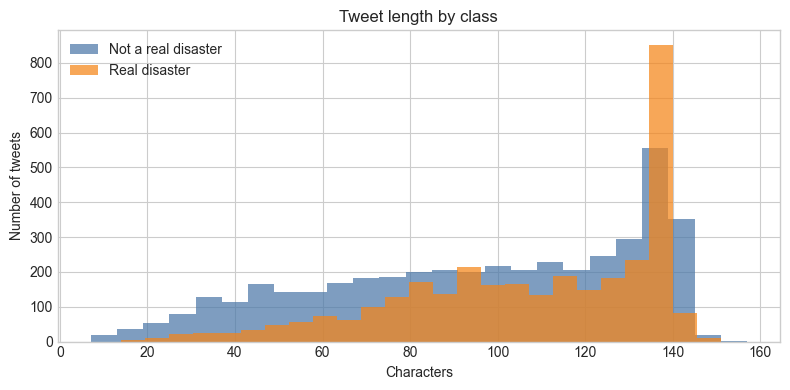

Validation protocol: 6,090 training tweets / 1,523 validation tweets


In [43]:
label_names = {0: "Not a real disaster", 1: "Real disaster"}
label_distribution = (
    train_df["target"]
    .value_counts()
    .sort_index()
    .rename(index=label_names)
    .rename("Tweets")
    .to_frame()
)
label_distribution["Share"] = label_distribution["Tweets"] / len(train_df)
print("Class balance")
display(label_distribution.style.format({"Share": "{:.1%}"}))

text_length = train_df["text"].fillna("").str.len()
fig, ax = plt.subplots(figsize=(8, 4))
for target, label, color in [(0, label_names[0], "#4C78A8"), (1, label_names[1], "#F58518")]:
    ax.hist(
        text_length[train_df["target"] == target],
        bins=25,
        alpha=0.72,
        label=label,
        color=color,
    )
ax.set_title("Tweet length by class")
ax.set_xlabel("Characters")
ax.set_ylabel("Number of tweets")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

X_train, X_valid, y_train, y_valid = train_test_split(
    train_df["text"].fillna(""),
    train_df["target"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_df["target"],
)
print(f"Validation protocol: {len(X_train):,} training tweets / {len(X_valid):,} validation tweets")

## 3. Establish a validation protocol

A stratified holdout keeps the class balance representative while reserving unseen examples for an honest comparison. Models are compared with threshold-based metrics (accuracy, balanced accuracy, precision, recall, and F1) plus ranking metrics (ROC-AUC and average precision). The text field is used as the sole feature in this baseline.

Validation leaderboard


Model,Accuracy,Balanced accuracy,Precision (real),Recall (real),F1 (macro),F1 (weighted),ROC-AUC,Average precision
Logistic Regression,0.816,0.803,0.839,0.708,0.808,0.813,0.871,0.864
Multinomial Naive Bayes,0.816,0.799,0.867,0.676,0.805,0.812,0.866,0.867


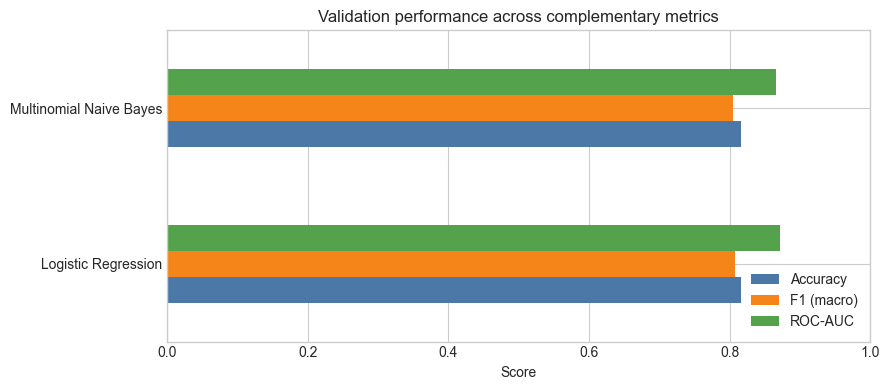

In [44]:
models = {
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("classifier", MultinomialNB()),
    ]),
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("classifier", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]),
}

validation_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)
    probabilities = model.predict_proba(X_valid)[:, 1]
    report = classification_report(y_valid, predictions, output_dict=True)
    validation_rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Balanced accuracy": balanced_accuracy_score(y_valid, predictions),
        "Precision (real)": report["1"]["precision"],
        "Recall (real)": report["1"]["recall"],
        "F1 (macro)": report["macro avg"]["f1-score"],
        "F1 (weighted)": report["weighted avg"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_valid, probabilities),
        "Average precision": average_precision_score(y_valid, probabilities),
    })

validation_results = pd.DataFrame(validation_rows).sort_values("F1 (macro)", ascending=False)
print("Validation leaderboard")
display(
    validation_results.style
    .format({column: "{:.3f}" for column in validation_results.columns[1:]})
    .hide(axis="index")
)

fig, ax = plt.subplots(figsize=(9, 4))
validation_results.plot.barh(
    x="Model",
    y=["Accuracy", "F1 (macro)", "ROC-AUC"],
    ax=ax,
    color=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set_title("Validation performance across complementary metrics")
ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

Selected model: Logistic Regression


,Precision,Recall,F1,Support
Not a real disaster,0.803,0.898,0.848,869
Real disaster,0.839,0.708,0.768,654
accuracy,0.816,0.816,0.816,1
macro avg,0.821,0.803,0.808,1523
weighted avg,0.819,0.816,0.813,1523


Confusion matrix


,Not a real disaster,Real disaster
Not a real disaster,780,89
Real disaster,191,463


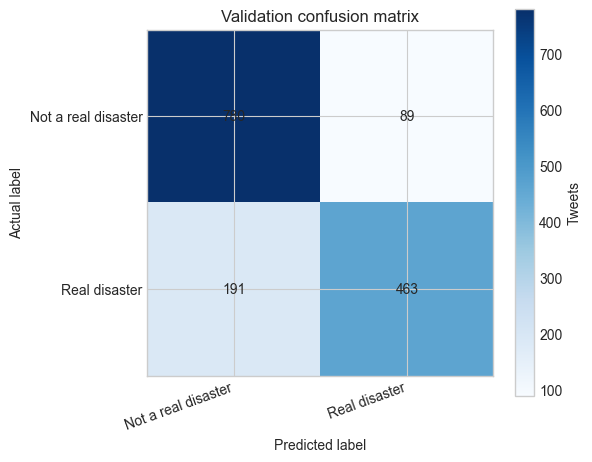

In [45]:
best_model_name = validation_results.iloc[0]["Model"]
best_model = models[best_model_name]
validation_predictions = best_model.predict(X_valid)

report = classification_report(
    y_valid,
    validation_predictions,
    target_names=[label_names[0], label_names[1]],
    output_dict=True,
)
report_table = pd.DataFrame(report).T.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1",
    "support": "Support",
})
print(f"Selected model: {best_model_name}")
display(
    report_table[["Precision", "Recall", "F1", "Support"]]
    .style.format({"Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}", "Support": "{:.0f}"})
)

confusion_table = pd.DataFrame(
    confusion_matrix(y_valid, validation_predictions),
    index=[label_names[0], label_names[1]],
    columns=[label_names[0], label_names[1]],
)
print("Confusion matrix")
display(confusion_table)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion_table.values, cmap="Blues")
ax.set_title("Validation confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_xticks(range(len(label_names)), confusion_table.columns, rotation=20, ha="right")
ax.set_yticks(range(len(label_names)), confusion_table.index)
for row in range(confusion_table.shape[0]):
    for column in range(confusion_table.shape[1]):
        ax.text(column, row, confusion_table.iloc[row, column], ha="center", va="center")
fig.colorbar(image, ax=ax, label="Tweets")
fig.tight_layout()
plt.show()

## 4. Interpret the selected model

The strongest features provide a useful sanity check. Positive weights favor the real-disaster class, while negative weights favor the non-disaster class. These associations describe the model's behavior, not causal evidence about the underlying events.

Most influential terms


Class,Term,Weight
Not a real disaster,new,-2.020
Not a real disaster,love,-1.917
Not a real disaster,bloody,-1.507
Not a real disaster,harm,-1.504
Not a real disaster,let,-1.503
Not a real disaster,ruin,-1.485
Not a real disaster,wrecked,-1.465
Not a real disaster,stretcher,-1.455
Not a real disaster,explode,-1.454
Not a real disaster,traumatised,-1.444


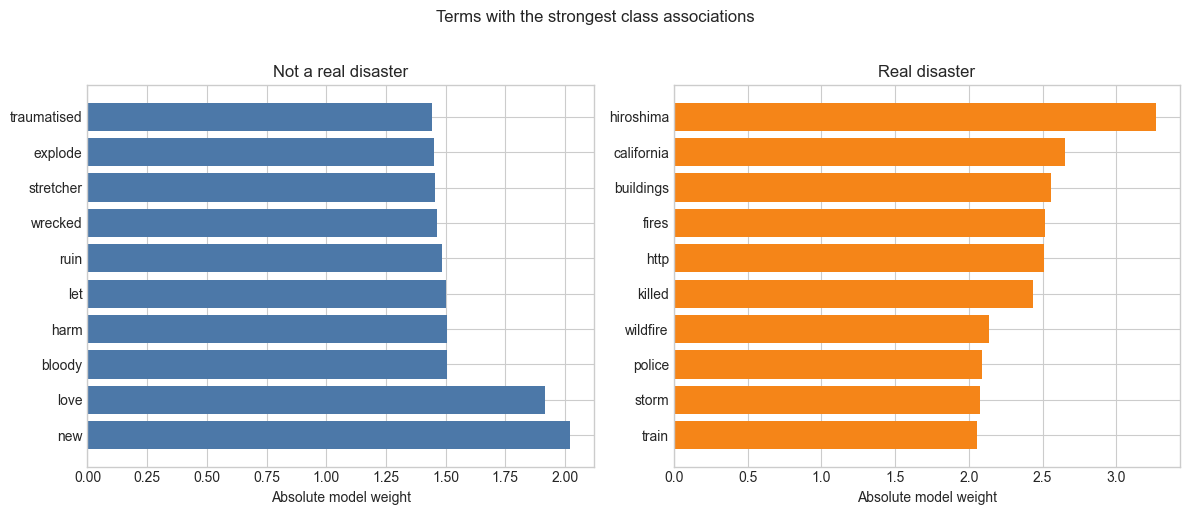

In [46]:
vectorizer = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["classifier"]
feature_names = vectorizer.get_feature_names_out()

if hasattr(classifier, "coef_"):
    feature_weights = classifier.coef_[0]
else:
    feature_weights = classifier.feature_log_prob_[1] - classifier.feature_log_prob_[0]

feature_table = pd.DataFrame({"Term": feature_names, "Weight": feature_weights})
top_real = feature_table.nlargest(10, "Weight").assign(Class=label_names[1])
top_non_disaster = feature_table.nsmallest(10, "Weight").assign(Class=label_names[0])
top_features = pd.concat([top_real, top_non_disaster]).sort_values("Weight")

print("Most influential terms")
display(
    top_features[["Class", "Term", "Weight"]]
    .style.format({"Weight": "{:.3f}"})
    .hide(axis="index")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
for axis, subset, title, color in [
    (axes[0], top_non_disaster.sort_values("Weight"), label_names[0], "#4C78A8"),
    (axes[1], top_real.sort_values("Weight"), label_names[1], "#F58518"),
]:
    axis.barh(subset["Term"], subset["Weight"].abs(), color=color)
    axis.set_title(title)
    axis.set_xlabel("Absolute model weight")
    axis.set_ylabel("")
fig.suptitle("Terms with the strongest class associations", y=1.02)
fig.tight_layout()
plt.show()

## 5. Train on all data and export

After validation and interpretation, the selected pipeline is retrained on every labeled tweet and used to create the final submission file.

In [47]:
final_model = models[best_model_name]
final_model.fit(train_df["text"].fillna(""), train_df["target"])
test_predictions = final_model.predict(test_df["text"].fillna(""))

submission = pd.DataFrame({"id": test_df["id"], "target": test_predictions})
print("Submission preview")
display(submission.head().style.hide(axis="index"))
print(f"Predictions generated: {len(submission):,}")

Submission preview


id,target
0,1
2,1
3,1
9,0
11,1


Predictions generated: 3,263


In [48]:
output_path = PROJECT_ROOT / "submission.csv"
submission.to_csv(output_path, index=False)
print(f"Submission saved: {output_path.name}")
print(f"Rows: {len(submission):,} | Columns: {', '.join(submission.columns)}")

Submission saved: submission.csv
Rows: 3,263 | Columns: id, target
